In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
nav.head()


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()
nav.head(10)

,amfi_code,date,nav,daily_return
0,119551,2022-01-03,54.3856,NaN
1,119551,2022-01-04,54.3474,-0.000702
2,119551,2022-01-05,54.6869,0.006247
3,119551,2022-01-06,55.4550,0.014045
4,119551,2022-01-07,55.3692,-0.001547
5,119551,2022-01-10,55.2835,-0.001548
6,119551,2022-01-11,56.0878,0.014549
7,119551,2022-01-12,56.4978,0.007310
8,119551,2022-01-13,56.2934,-0.003618
9,119551,2022-01-14,56.5926,0.005315


In [6]:
nav["daily_return"].isna().sum()

np.int64(40)

In [7]:
nav["daily_return"].isna().groupby(nav["amfi_code"]).sum().value_counts()

daily_return
1    40
Name: count, dtype: int64

In [8]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [9]:
nav["date"].min(), nav["date"].max()

('2022-01-03', '2026-05-29')

In [10]:
nav[nav["date"].isin(["2025-05-29", "2026-05-29"])].groupby("date")["amfi_code"].nunique()

date
2025-05-29    40
2026-05-29    40
Name: amfi_code, dtype: int64

In [11]:
nav_1y = nav[nav["date"].isin(["2025-05-29", "2026-05-29"])].copy()

In [12]:
cagr_1y = nav_1y.pivot(index="amfi_code", columns="date", values="nav").reset_index()

In [13]:
cagr_1y["cagr_1yr"] = (cagr_1y["2026-05-29"] / cagr_1y["2025-05-29"]) - 1

In [14]:
cagr_1y.head()

date,amfi_code,2025-05-29,2026-05-29,cagr_1yr
0,100016,596.8877,583.6113,-0.022243
1,100025,30.7452,31.8843,0.037050
2,100033,223.1951,342.0072,0.532324
3,101206,522.7639,773.2939,0.479241
4,101207,71.0180,53.9836,-0.239860


In [15]:
nav[nav["date"].isin(["2023-05-29", "2026-05-29"])].groupby("date")["amfi_code"].nunique()

date
2023-05-29    40
2026-05-29    40
Name: amfi_code, dtype: int64

In [16]:
nav_3y = nav[nav["date"].isin(["2023-05-29", "2026-05-29"])].copy()

In [17]:
cagr_3y = nav_3y.pivot(index="amfi_code", columns="date", values="nav").reset_index()

In [18]:
cagr_3y["cagr_3yr"] = (cagr_3y["2026-05-29"] / cagr_3y["2023-05-29"]) ** (1 / 3) - 1

In [19]:
cagr_3y.head()

date,amfi_code,2023-05-29,2026-05-29,cagr_3yr
0,100016,561.5519,583.6113,0.012926
1,100025,28.4135,31.8843,0.039164
2,100033,147.2155,342.0072,0.324425
3,101206,360.4971,773.2939,0.289677
4,101207,61.3081,53.9836,-0.041524


In [20]:
cagr_table = cagr_1y[["amfi_code", "cagr_1yr"]].merge(cagr_3y[["amfi_code", "cagr_3yr"]],on="amfi_code")

In [21]:
cagr_table.shape

(40, 3)

In [22]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

In [23]:
cagr_table = fund_master[["amfi_code", "scheme_name", "fund_house", "category"]].merge(cagr_table,on="amfi_code")

In [24]:
cagr_table.shape

(40, 6)

In [25]:
cagr_table.head()

,amfi_code,scheme_name,fund_house,category,cagr_1yr,cagr_3yr
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.604373,0.304565
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,0.057061,0.162674
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.827761,0.266699
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,0.139478,-0.013374
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Debt,0.055220,0.058404


In [28]:
cagr_table = cagr_table.sort_values("cagr_3yr", ascending=False)
cagr_table.head(10)

,amfi_code,scheme_name,fund_house,category,cagr_1yr,cagr_3yr
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,0.222611,0.351118
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.203607,0.340009
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,0.130643,0.324874
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.532324,0.324425
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.296047,0.317775
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.604373,0.304565
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.266571,0.295828
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.397518,0.291789
28,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.479241,0.289677
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.651387,0.270004


In [30]:
rf_annual = 0.065
rf_daily = rf_annual / 252
rf_annual

0.065

In [31]:
sharpe = nav.groupby("amfi_code")["daily_return"].agg(["mean", "std"])

In [33]:
sharpe["sharpe_ratio"] = (sharpe["mean"] - rf_daily) / sharpe["std"] * np.sqrt(252)
sharpe.head()

,mean,std,sharpe_ratio
amfi_code,,,
100016,0.000142,0.009164,-0.201517
100025,0.000170,0.002460,-0.567095
100033,0.001080,0.011929,1.093699
101206,0.000852,0.009177,1.027213
101207,0.000424,0.016251,0.162661


In [34]:
sharpe.sort_values("sharpe_ratio", ascending=False).head(10)

,mean,std,sharpe_ratio
amfi_code,,,
148567,0.001074,0.008941,1.448291
120843,0.001082,0.010008,1.306744
148569,0.001124,0.011134,1.234930
119551,0.000917,0.008656,1.208267
120505,0.001161,0.012152,1.180101
149323,0.001055,0.011179,1.132122
100033,0.001080,0.011929,1.093699
118632,0.000865,0.008913,1.081659
101206,0.000852,0.009177,1.027213


In [37]:
sharpe["sharpe_rank"] = sharpe["sharpe_ratio"].rank(ascending=False, method="min").astype(int)

In [38]:
sharpe.sort_values("sharpe_rank").head(10)

,mean,std,sharpe_ratio,sharpe_rank
amfi_code,,,,
148567,0.001074,0.008941,1.448291,1
120843,0.001082,0.010008,1.306744,2
148569,0.001124,0.011134,1.234930,3
119551,0.000917,0.008656,1.208267,4
120505,0.001161,0.012152,1.180101,5
149323,0.001055,0.011179,1.132122,6
100033,0.001080,0.011929,1.093699,7
118632,0.000865,0.008913,1.081659,8
101206,0.000852,0.009177,1.027213,9


In [39]:
sharpe["sharpe_rank"].max()

np.int64(40)

In [41]:
downside = nav[nav["daily_return"] < 0].groupby("amfi_code")["daily_return"].agg(["mean", "std"])
downside.head()

,mean,std
amfi_code,,
100016,-0.007131,0.005261
100025,-0.001858,0.001481
100033,-0.008999,0.007133
101206,-0.006947,0.005238
101207,-0.012736,0.009555


In [42]:
downside["sortino_ratio"] = (sharpe["mean"] - rf_daily) / downside["std"] * np.sqrt(252)
downside.sort_values("sortino_ratio", ascending=False).head(10)

,mean,std,sortino_ratio
amfi_code,,,
148567,-0.006875,0.005428,2.385644
120843,-0.007490,0.005531,2.364320
148569,-0.008251,0.006404,2.146914
119551,-0.006657,0.004887,2.140267
120505,-0.009122,0.007067,2.029353
149323,-0.008685,0.006750,1.875101
118632,-0.006823,0.005211,1.850133
100033,-0.008999,0.007133,1.829134
120504,-0.007126,0.005145,1.805294


In [43]:
downside["sortino_rank"] = downside["sortino_ratio"].rank(ascending=False, method="min").astype(int)
downside.sort_values("sortino_rank").head(10)

,mean,std,sortino_ratio,sortino_rank
amfi_code,,,,
148567,-0.006875,0.005428,2.385644,1
120843,-0.007490,0.005531,2.364320,2
148569,-0.008251,0.006404,2.146914,3
119551,-0.006657,0.004887,2.140267,4
120505,-0.009122,0.007067,2.029353,5
149323,-0.008685,0.006750,1.875101,6
118632,-0.006823,0.005211,1.850133,7
100033,-0.008999,0.007133,1.829134,8
120504,-0.007126,0.005145,1.805294,9


In [46]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [47]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [48]:
benchmark["date"] = pd.to_datetime(benchmark["date"])
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()
nifty100 = nifty100.sort_values("date")

In [49]:
nifty100["market_return"] = nifty100["close_value"].pct_change()
nifty100.head()

,date,index_name,close_value,market_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [50]:
market = nifty100[["date", "market_return"]]

In [53]:
nav["date"] = pd.to_datetime(nav["date"])
nifty100["date"] = pd.to_datetime(nifty100["date"])
market = nifty100[["date", "market_return"]]

In [56]:
returns = nav[["amfi_code", "date", "daily_return"]].merge(market,on="date",how="inner")
returns.head()

,amfi_code,date,daily_return,market_return
0,119551,2022-01-03,NaN,NaN
1,119551,2022-01-04,-0.000702,-0.013540
2,119551,2022-01-05,0.006247,0.004003
3,119551,2022-01-06,0.014045,-0.002935
4,119551,2022-01-07,-0.001547,0.006150


In [59]:
test_fund = returns[returns["amfi_code"] == 100016].dropna()
test_fund.shape

(1149, 4)

In [62]:
from scipy.stats import linregress
test_regression = linregress(test_fund["market_return"],test_fund["daily_return"])
test_regression

LinregressResult(slope=np.float64(-0.05826843143880891), intercept=np.float64(0.00014871352235886037), rvalue=np.float64(-0.05162395469288772), pvalue=np.float64(0.08026442483699604), stderr=np.float64(0.033282877789576594), intercept_stderr=np.float64(0.00027015059491085184))

In [64]:
alpha_beta_results = []

for code, group in returns.groupby("amfi_code"):
    group = group.dropna(subset=["daily_return", "market_return"])
    regression = linregress(group["market_return"], group["daily_return"])
    alpha_beta_results.append({
        "amfi_code": code,
        "alpha": regression.intercept * 252,
        "beta": regression.slope
    })

In [66]:
alpha_beta = pd.DataFrame(alpha_beta_results)
alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [71]:
alpha_beta["alpha_rank"] = alpha_beta["alpha"].rank(ascending=False, method="min").astype(int)
alpha_beta.sort_values("alpha_rank").head(10)

,amfi_code,alpha,beta,alpha_rank
21,119598,0.303370,-0.023196,1
39,149324,0.300579,0.011455,2
25,120505,0.292636,0.000549,3
36,148569,0.282704,0.018134,4
30,120843,0.273305,-0.022830,5
2,100033,0.271954,0.005104,6
34,148567,0.269838,0.023684,7
38,149323,0.265986,-0.002523,8
16,119094,0.260767,-0.066265,9
19,119551,0.232010,-0.031751,10


In [75]:
nav["running_max"] = nav.groupby("amfi_code")["nav"].cummax()

In [76]:
nav[["amfi_code", "date", "nav", "running_max"]].head(10)

,amfi_code,date,nav,running_max
0,119551,2022-01-03,54.3856,54.3856
1,119551,2022-01-04,54.3474,54.3856
2,119551,2022-01-05,54.6869,54.6869
3,119551,2022-01-06,55.4550,55.4550
4,119551,2022-01-07,55.3692,55.4550
5,119551,2022-01-10,55.2835,55.4550
6,119551,2022-01-11,56.0878,56.0878
7,119551,2022-01-12,56.4978,56.4978
8,119551,2022-01-13,56.2934,56.4978
9,119551,2022-01-14,56.5926,56.5926


In [78]:
nav["drawdown"] = nav["nav"] / nav["running_max"] - 1
nav[["amfi_code", "date", "nav", "running_max", "drawdown"]].head(10)

,amfi_code,date,nav,running_max,drawdown
0,119551,2022-01-03,54.3856,54.3856,0.000000
1,119551,2022-01-04,54.3474,54.3856,-0.000702
2,119551,2022-01-05,54.6869,54.6869,0.000000
3,119551,2022-01-06,55.4550,55.4550,0.000000
4,119551,2022-01-07,55.3692,55.4550,-0.001547
5,119551,2022-01-10,55.2835,55.4550,-0.003093
6,119551,2022-01-11,56.0878,56.0878,0.000000
7,119551,2022-01-12,56.4978,56.4978,0.000000
8,119551,2022-01-13,56.2934,56.4978,-0.003618
9,119551,2022-01-14,56.5926,56.5926,0.000000


In [80]:
max_drawdown = nav.groupby("amfi_code")["drawdown"].min().reset_index()
max_drawdown.sort_values("drawdown").head(10)

,amfi_code,drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


In [81]:
worst_row = nav.loc[nav["drawdown"].idxmin()]
worst_row

amfi_code                    119599
date            2025-10-28 00:00:00
nav                         78.6152
daily_return              -0.012874
running_max                165.7647
drawdown                  -0.525742
Name: 4446, dtype: object

In [83]:
peak_date = nav[
    (nav["amfi_code"] == worst_row["amfi_code"]) &
    (nav["nav"] == worst_row["running_max"]) &
    (nav["date"] <= worst_row["date"])
].iloc[-1]

peak_date

amfi_code                    119599
date            2023-01-17 00:00:00
nav                        165.7647
daily_return               0.028082
running_max                165.7647
drawdown                        0.0
Name: 3721, dtype: object

In [84]:
max_drawdown = max_drawdown.rename(columns={"drawdown": "max_drawdown"})
max_drawdown.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [91]:
scorecard = cagr_table[["amfi_code", "scheme_name", "fund_house", "cagr_3yr"]].merge(
    sharpe[["sharpe_ratio"]],
    left_on="amfi_code",
    right_index=True
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    fund_master[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    max_drawdown[["amfi_code", "max_drawdown"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,fund_house,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown
0,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,0.351118,0.998231,0.260767,1.38,-0.209609
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,0.340009,1.448291,0.269838,1.46,-0.112657
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,0.324874,1.026524,0.211948,0.80,-0.125883
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,0.324425,1.093699,0.271954,1.38,-0.162172
4,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,0.317775,1.180101,0.292636,1.36,-0.181885


In [97]:
scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False, method="min").astype(int)
scorecard["alpha_score"] = (40 - scorecard["alpha_rank"]) / 39 * 100
scorecard[["amfi_code", "alpha", "alpha_rank", "alpha_score"]].sort_values("alpha_rank").head(10)

,amfi_code,alpha,alpha_rank,alpha_score
11,119598,0.303370,1,100.000000
9,149324,0.300579,2,97.435897
4,120505,0.292636,3,94.871795
7,148569,0.282704,4,92.307692
6,120843,0.273305,5,89.743590
3,100033,0.271954,6,87.179487
1,148567,0.269838,7,84.615385
10,149323,0.265986,8,82.051282
0,119094,0.260767,9,79.487179
5,119551,0.232010,10,76.923077


In [99]:
scorecard["expense_score"] = (40 - scorecard["expense_rank"]) / 39 * 100
scorecard[["amfi_code", "expense_ratio_pct", "expense_rank", "expense_score"]].sort_values("expense_rank").head(10)

,amfi_code,expense_ratio_pct,expense_rank,expense_score
32,118636,0.55,1,100.000000
33,100025,0.56,2,97.435897
29,120844,0.60,3,94.871795
22,119552,0.66,4,92.307692
14,118633,0.72,5,89.743590
37,119599,0.72,5,89.743590
28,120507,0.74,7,84.615385
15,119093,0.75,8,82.051282
31,119120,0.77,9,79.487179
25,125498,0.78,10,76.923077


In [100]:
scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=False, method="min").astype(int)
scorecard[["amfi_code", "max_drawdown", "drawdown_rank"]].sort_values("drawdown_rank").head(10)

,amfi_code,max_drawdown,drawdown_rank
28,120507,-0.000977,1
29,120844,-0.001163,2
30,101208,-0.001622,3
33,100025,-0.043083,4
31,119120,-0.043287,5
32,118636,-0.083164,6
17,102885,-0.108599,7
1,148567,-0.112657,8
8,101206,-0.112916,9
16,118635,-0.116506,10


In [101]:
scorecard["drawdown_score"] = (40 - scorecard["drawdown_rank"]) / 39 * 100
scorecard[["amfi_code", "max_drawdown", "drawdown_rank", "drawdown_score"]].sort_values("drawdown_rank").head(10)

,amfi_code,max_drawdown,drawdown_rank,drawdown_score
28,120507,-0.000977,1,100.000000
29,120844,-0.001163,2,97.435897
30,101208,-0.001622,3,94.871795
33,100025,-0.043083,4,92.307692
31,119120,-0.043287,5,89.743590
32,118636,-0.083164,6,87.179487
17,102885,-0.108599,7,84.615385
1,148567,-0.112657,8,82.051282
8,101206,-0.112916,9,79.487179
16,118635,-0.116506,10,76.923077


In [102]:
scorecard["cagr_rank"] = scorecard["cagr_3yr"].rank(
    ascending=False, method="min"
).astype(int)
scorecard["cagr_score"] = (40 - scorecard["cagr_rank"]) / 39 * 100

scorecard["sharpe_score"] = (40 - scorecard["sharpe_rank"]) / 39 * 100

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True, method="min"
).astype(int)
scorecard["expense_score"] = (40 - scorecard["expense_rank"]) / 39 * 100

scorecard["overall_score"] = (
    0.30 * scorecard["cagr_score"]
    + 0.25 * scorecard["sharpe_score"]
    + 0.20 * scorecard["alpha_score"]
    + 0.15 * scorecard["expense_score"]
    + 0.10 * scorecard["drawdown_score"]
)

scorecard["overall_rank"] = scorecard["overall_score"].rank(
    ascending=False, method="min"
).astype(int)

scorecard.sort_values("overall_rank")[["overall_rank", "scheme_name", "overall_score"]].head(10)

,overall_rank,scheme_name,overall_score
1,1,Mirae Asset Large Cap Fund - Regular - Growth,85.897436
4,2,ICICI Pru Midcap Fund - Regular - Growth,81.794872
6,3,Kotak Flexicap Fund - Regular - Growth,81.538462
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.641026
2,5,ICICI Pru Bluechip Fund - Direct - Growth,79.487179
0,6,Axis Midcap Fund - Regular - Growth,76.794872
5,7,SBI Bluechip Fund - Regular Plan - Growth,74.358974
7,8,Mirae Asset Tax Saver Fund - Regular - Growth,73.205128
8,9,ABSL Frontline Equity Fund - Regular - Growth,67.564103
11,10,SBI Small Cap Fund - Regular Plan - Growth,66.538462


In [106]:
scorecard.to_csv("../data/processed/fund_scorecard.csv", index=False)
import os
os.path.exists("../data/processed/fund_scorecard.csv")

True

In [107]:
alpha_beta.shape

(40, 4)

In [108]:
alpha_beta.to_csv("../data/processed/alpha_beta.csv", index=False)
import os
os.path.exists("../data/processed/alpha_beta.csv")

True

In [109]:
top5 = scorecard.sort_values("overall_rank").head(5)

top5[["amfi_code", "scheme_name", "overall_score", "overall_rank"]]

,amfi_code,scheme_name,overall_score,overall_rank
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,85.897436,1
4,120505,ICICI Pru Midcap Fund - Regular - Growth,81.794872,2
6,120843,Kotak Flexicap Fund - Regular - Growth,81.538462,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.641026,4
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,79.487179,5


In [111]:
benchmark_nav["fund_return"] = benchmark_nav.groupby("amfi_code")["nav"].pct_change()
benchmark_nav[["amfi_code", "date", "nav", "fund_return"]].head(10)

,amfi_code,date,nav,fund_return
8415,100033,2023-05-29,147.2155,NaN
8416,100033,2023-05-30,147.2007,-0.000101
8417,100033,2023-05-31,147.4640,0.001789
8418,100033,2023-06-01,146.5954,-0.005890
8419,100033,2023-06-02,145.8015,-0.005416
8420,100033,2023-06-05,146.4025,0.004122
8421,100033,2023-06-06,148.1654,0.012041
8422,100033,2023-06-07,147.2075,-0.006465
8423,100033,2023-06-08,145.7830,-0.009677
8424,100033,2023-06-09,146.9565,0.008050


In [112]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [113]:
benchmark_3yr = benchmark[
    (benchmark["date"] >= "2023-05-29") &
    (benchmark["date"] <= "2026-05-29") &
    (benchmark["index_name"].isin(["NIFTY50", "NIFTY100"]))
].copy()
benchmark_3yr["benchmark_return"] = benchmark_3yr.groupby("index_name")["close_value"].pct_change()
benchmark_3yr.head(10)

,date,index_name,close_value,benchmark_return
365,2023-05-29,NIFTY50,24688.69,NaN
366,2023-05-30,NIFTY50,24558.17,-0.005287
367,2023-05-31,NIFTY50,24476.07,-0.003343
368,2023-06-01,NIFTY50,24375.89,-0.004093
369,2023-06-02,NIFTY50,24398.93,0.000945
370,2023-06-05,NIFTY50,24819.70,0.017245
371,2023-06-06,NIFTY50,24464.63,-0.014306
372,2023-06-07,NIFTY50,24541.65,0.003148
373,2023-06-08,NIFTY50,24640.11,0.004012
374,2023-06-09,NIFTY50,24544.89,-0.003864


In [114]:
nifty50 = benchmark_3yr[benchmark_3yr["index_name"] == "NIFTY50"][["date", "benchmark_return"]].rename(columns={"benchmark_return": "nifty50_return"})
nifty100 = benchmark_3yr[benchmark_3yr["index_name"] == "NIFTY100"][["date", "benchmark_return"]].rename(columns={"benchmark_return": "nifty100_return"})

In [119]:
tracking_error = []

for code, group in benchmark_comparison.groupby("amfi_code"):
    nifty50_te = (group["fund_return"] - group["nifty50_return"]).dropna().std() * np.sqrt(252)
    nifty100_te = (group["fund_return"] - group["nifty100_return"]).dropna().std() * np.sqrt(252)

    tracking_error.append({
        "amfi_code": code,
        "tracking_error_nifty50": nifty50_te,
        "tracking_error_nifty100": nifty100_te
    })

tracking_error = pd.DataFrame(tracking_error)
tracking_error

,amfi_code,tracking_error_nifty50,tracking_error_nifty100
0,100033,0.228222,0.224976
1,120504,0.188211,0.187299
2,120505,0.228447,0.232661
3,120843,0.205067,0.206540
4,148567,0.191868,0.187974


In [120]:
comparison = benchmark_comparison.copy()
comparison["fund_index"] = comparison.groupby("amfi_code")["fund_return"].transform(lambda x: (1 + x.fillna(0)).cumprod() * 100)
comparison["nifty50_index"] = (1 + comparison["nifty50_return"].fillna(0)).cumprod() * 100
comparison["nifty100_index"] = (1 + comparison["nifty100_return"].fillna(0)).cumprod() * 100

In [121]:
comparison[["date", "amfi_code", "fund_index", "nifty50_index", "nifty100_index"]].tail()

,date,amfi_code,fund_index,nifty50_index,nifty100_index
3920,2026-05-25,148567,239.742614,23.313316,342.729323
3921,2026-05-26,148567,240.269883,23.610447,342.416612
3922,2026-05-27,148567,241.490458,23.745315,347.067390
3923,2026-05-28,148567,243.627013,23.613934,350.428323
3924,2026-05-29,148567,240.615334,23.737727,350.754568


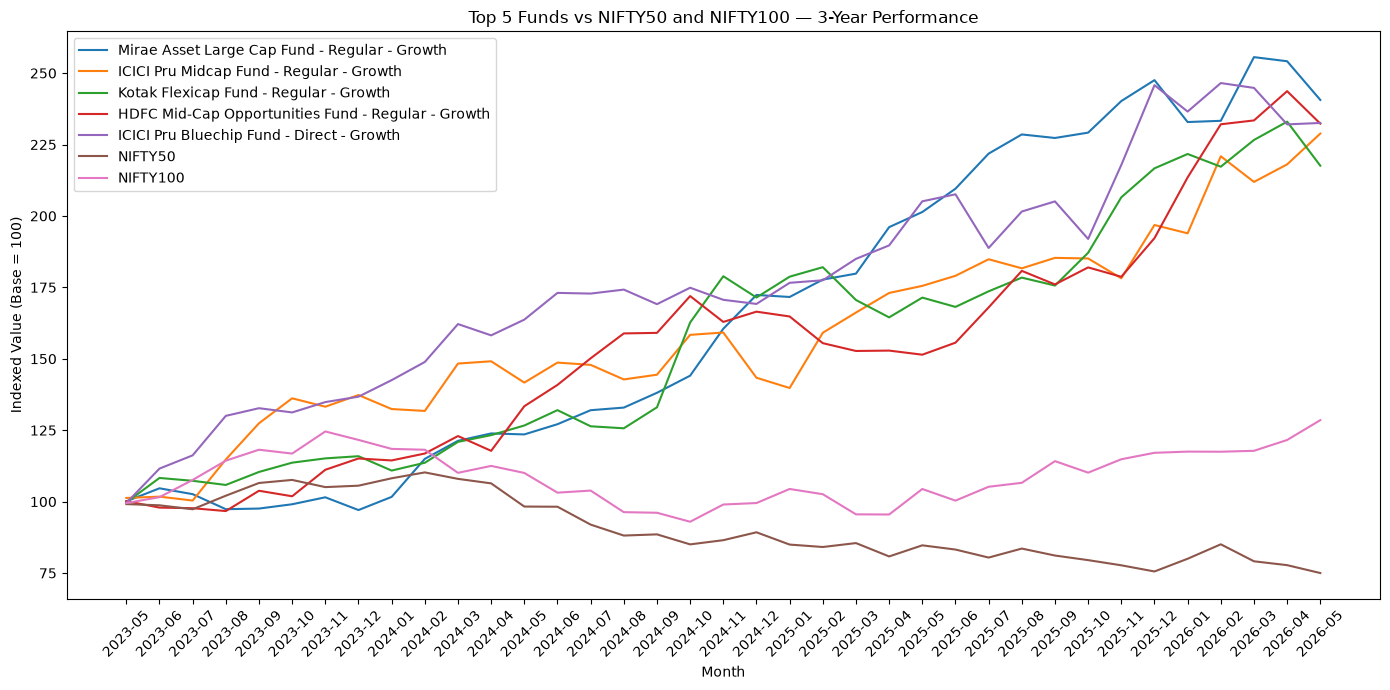

In [134]:
fig, ax = plt.subplots(figsize=(14, 7))

for code in top5["amfi_code"]:
    fund_data = monthly_comparison[monthly_comparison["amfi_code"] == code]
    name = top5.loc[top5["amfi_code"] == code, "scheme_name"].iloc[0]
    ax.plot(fund_data["month"].astype(str), fund_data["fund_index"], label=name)

benchmark_data = monthly_comparison.groupby("month").first().reset_index()

ax.plot(benchmark_data["month"].astype(str), benchmark_data["nifty50_index"], label="NIFTY50")
ax.plot(benchmark_data["month"].astype(str), benchmark_data["nifty100_index"], label="NIFTY100")

ax.set_title("Top 5 Funds vs NIFTY50 and NIFTY100 — 3-Year Performance")
ax.set_xlabel("Month")
ax.set_ylabel("Indexed Value (Base = 100)")
ax.tick_params(axis="x", rotation=45)
ax.legend()

fig.tight_layout()
fig.savefig("../reports/benchmark_comparison_top5.png", dpi=300, bbox_inches="tight")
plt.show()